In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [ ]:
# Define the four possible functions for the Deutsch algorithm
def deutsch_function(case: int):
    if case not in [1, 2, 3, 4]:
        raise ValueError("Case must be an integer between 1 and 4.")
    
    f = QuantumCircuit(2)
    if case in [2, 3]: # Balanced function (Same output for both inputs)
        f.cx(0, 1)
    if case in [3, 4]: # Balanced functions (Different output for both inputs)
        f.x(1)
    return f

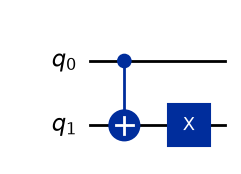

In [5]:
display(deutsch_function(3).draw(output="mpl"))

In [ ]:
# Compile the circuit for the Deutsch algorithm
def compile_circuit(function: QuantumCircuit):
    n = function.num_qubits - 1 # Number of input qubits
    qc = QuantumCircuit(n + 1, n)
    
    qc.x(n) # Initialize the output qubit to |1>
    qc.h(range(n+1)) # Apply Hadamard gates to all qubits
    qc.barrier()
    
    qc.compose(function, inplace=True) # Apply the oracle function
    qc.barrier()
    
    qc.h(range(n)) # Apply Hadamard gates to the input qubits
    qc.measure(range(n), range(n)) # Measure the input qubits
    return qc
    

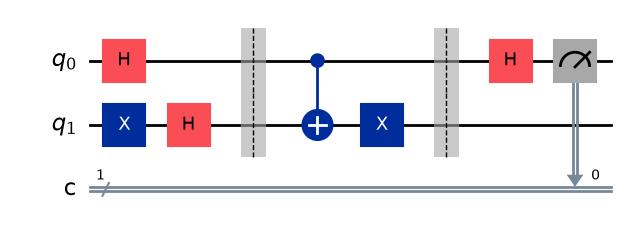

In [7]:
display(compile_circuit(deutsch_function(3)).draw(output="mpl"))

In [8]:
def deutsch_algorithm(function: QuantumCircuit):
    qc = compile_circuit(function)
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    
    if measurements[0] == '0':
        return "The function is constant."
    return "The function is balanced."

In [9]:
f = deutsch_function(3)
display(deutsch_algorithm(f))

'The function is balanced.'